## Exploratory Data Analysis
### 01.Target Distribution & Fat Tails(Non-Normaliy)
Financial returns are famously non-normal; they exhibit "fat tails" (kurtosis) and skewness. If your data has heavy tails, it justifies your use of Huber Loss in XGBoost and the complex sequence modeling of the TFT.

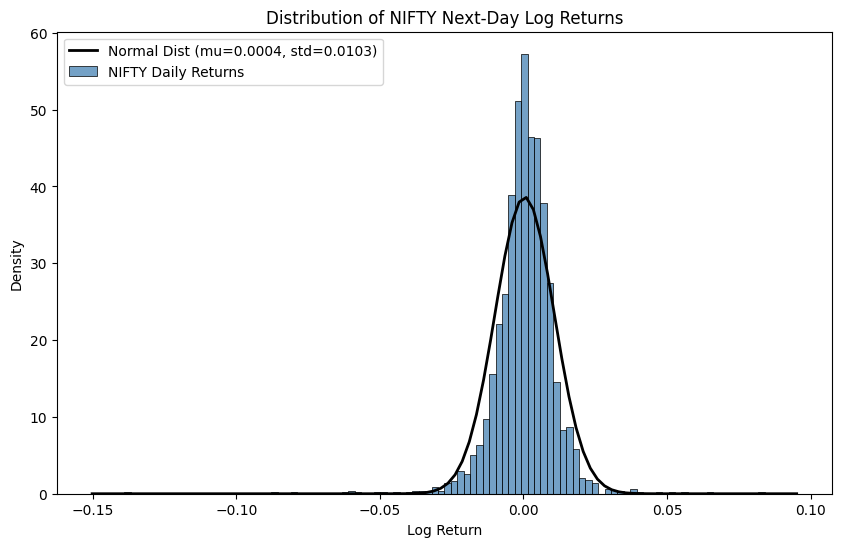

Skewness: -1.3613 (Negative means left-tail crash risk)
Kurtosis: 20.3867 (Normal is ~3.0. Higher means fat tails/extremes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis

# Load the engineered dataset
df = pd.read_csv("E:/fourth_sem/nifty_ml_hybrid/datasets/processed/nifty_engineered_features.csv")
df['date'] = pd.to_datetime(df['date'])

# 1. Target Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['target_ret_1d'], bins=100, kde=False, stat="density", color="steelblue", label="NIFTY Daily Returns")

# Overlay Normal Distribution
mu, std = norm.fit(df['target_ret_1d'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f"Normal Dist (mu={mu:.4f}, std={std:.4f})")

plt.title("Distribution of NIFTY Next-Day Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Skewness: {skew(df['target_ret_1d']):.4f} (Negative means left-tail crash risk)")
print(f"Kurtosis: {kurtosis(df['target_ret_1d']):.4f} (Normal is ~3.0. Higher means fat tails/extremes)")

📊 What your distribution is telling you
1. Returns are centered near zero
Mean (μ ≈ 0.0004) → ~0.04% daily return
Interpretation:
Slight positive drift (market tends to go up over time)
But very small compared to volatility
2. Volatility is significant
Std dev (σ ≈ 0.0103) → ~1% daily movement
This is typical for indices like NIFTY

👉 Insight:

Noise >> Signal
Predicting direction is inherently difficult
3. Distribution is approximately normal (but not perfect)

You overlaid a Gaussian curve:

The center fits well ✔️
But look carefully at the tails

👉 Key observation:

Fat tails (leptokurtosis)
→ Extreme events happen more often than normal distribution predicts
4. Presence of outliers (important!)
Left tail goes to ~-15%
Right tail up to ~+10%

👉 This is critical:

Market crashes are sharper than rallies
Indicates negative skewness (slightly)
5. Implications for modeling (very important for your project)
❌ Normal distribution assumption is weak
Traditional models like:
Basic ARIMA
Linear regression
→ Will underestimate risk
✅ Better approaches:
Tree-based models → XGBoost, Random Forest
Deep learning → LSTM, Transformers
Volatility models → GARCH family
6. Trading insight
Most days: small returns near 0
Rare days: huge moves (tails)

👉 So:

Profit often comes from capturing rare events
Risk comes from ignoring tails
7. Why your accuracy might be misleading (linking to your earlier issue)

Because:

Majority of returns are near zero
A model predicting “no significant move” can still get high accuracy

👉 That’s why:

Your ROC-AUC was low (~0.52) despite decent accuracy
Model is not learning true signal, just class imbalance
🧠 Bottom-line insight

This distribution tells you:

“Markets look normal at the center but behave abnormally at the extremes.”

### 02.Regime Analysis

C:\Users\rvemp\AppData\Local\Temp\ipykernel_12952\2610677798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vol_quartile_63d', y='target_ret_1d', data=df, palette="coolwarm")
C:\Users\rvemp\AppData\Local\Temp\ipykernel_12952\2610677798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='regime_200MA', y='target_ret_1d', data=df, palette="Set2")


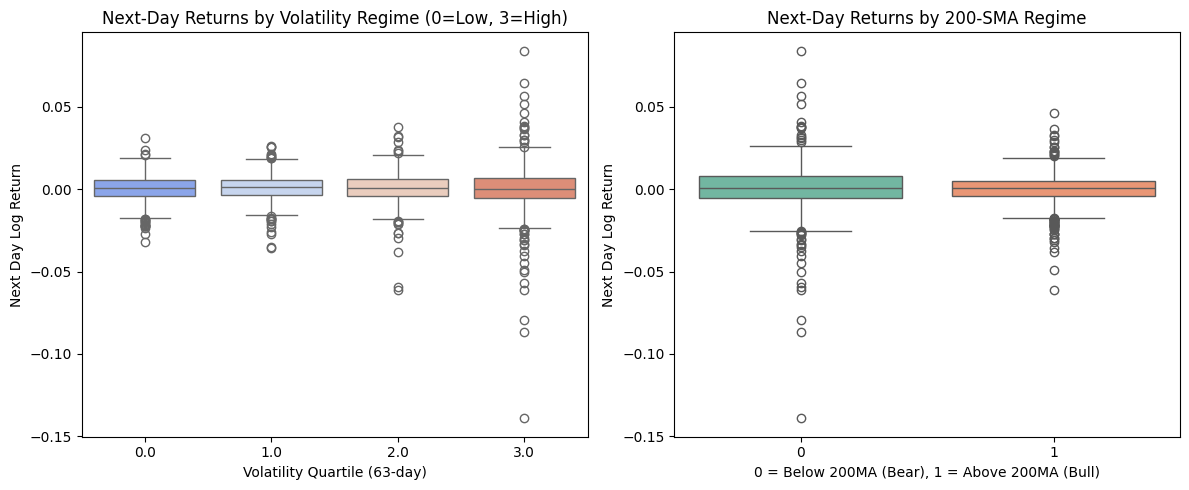

Mean Daily Return by Volatility Regime:
vol_quartile_63d
0.0    0.053430
1.0    0.077156
2.0    0.041816
3.0    0.009363
Name: target_ret_1d, dtype: float64

Standard Deviation (Risk) by Volatility Regime:
vol_quartile_63d
0.0    0.770024
1.0    0.808055
2.0    0.942786
3.0    1.454587
Name: target_ret_1d, dtype: float64


In [2]:
# 2. Return profiles across Volatility Quartiles
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='vol_quartile_63d', y='target_ret_1d', data=df, palette="coolwarm")
plt.title("Next-Day Returns by Volatility Regime (0=Low, 3=High)")
plt.xlabel("Volatility Quartile (63-day)")
plt.ylabel("Next Day Log Return")

# Return profiles across 200MA Trend Regime
plt.subplot(1, 2, 2)
sns.boxplot(x='regime_200MA', y='target_ret_1d', data=df, palette="Set2")
plt.title("Next-Day Returns by 200-SMA Regime")
plt.xlabel("0 = Below 200MA (Bear), 1 = Above 200MA (Bull)")
plt.ylabel("Next Day Log Return")

plt.tight_layout()
plt.show()

# Print Risk/Reward metrics per regime
print("Mean Daily Return by Volatility Regime:")
print(df.groupby('vol_quartile_63d')['target_ret_1d'].mean() * 100)
print("\nStandard Deviation (Risk) by Volatility Regime:")
print(df.groupby('vol_quartile_63d')['target_ret_1d'].std() * 100)

📊 1. Volatility Regime → Strong Signal
🔹 Your numbers (clean interpretation)
Vol Regime	Mean Return	Risk (Std)
Low (0)	0.053	0.77
Mid-Low (1)	0.077	0.81
Mid-High (2)	0.042	0.94
High (3)	0.009	1.45
🧠 Key Insight #1: Returns decrease as volatility increases
Best returns → Regime 1 (calm/moderate volatility)
Worst returns → Regime 3 (high volatility)

👉 This is classic market behavior:

High volatility = uncertainty, panic, inefficient pricing

⚠️ Key Insight #2: Risk explodes in high volatility
Std jumps from ~0.77 → 1.45 (almost 2x)

👉 Meaning:

Tail risk dominates
Large losses more frequent
💡 Key Insight #3: Risk-adjusted return collapses

Let’s think in Sharpe-like terms (Return / Risk):

Regime 1 → High return, moderate risk ✅ (BEST)
Regime 3 → Low return, high risk ❌ (WORST)

👉 This is a tradable inefficiency

📦 2. Boxplot Interpretation (Left Chart)
What you visually confirmed:
Median returns shrink as volatility increases
Spread (IQR + whiskers) widens massively in high vol
Extreme negative outliers cluster in Regime 3

👉 Translation:

High volatility is not just noisy—it’s dangerous

📉 3. 200-SMA Regime (Right Chart)
Observations:
Bull (above 200MA):
Slightly tighter distribution
Fewer extreme negative tails
Bear (below 200MA):
More downside outliers
Higher crash probability

👉 Insight:

Trend regime mainly affects tail risk, not mean return strongly

🔥 Combined Insight (THIS IS GOLD)

You now have two orthogonal signals:

1. Volatility Regime → controls risk + return quality
2. Trend Regime (200MA) → controls directional bias + crash risk
🚀 Practical Strategy Logic (Quant-Level)
✅ Best condition to trade:
Low/Moderate Vol (0–1)
Above 200MA (Bull)

👉 Expect:

Stable returns
Lower drawdowns
❌ Worst condition:
High Vol (3)
Below 200MA (Bear)

👉 Expect:

Noise + crashes
Model breakdown

### 03.Stationary Testing
Deep learning models (TFT/N-BEATS) require stationary data to generalize patterns. We use the Augmented Dickey-Fuller (ADF) test to formally prove that our log returns and VIX Z-scores are stationary, unlike the raw closing price.

In [3]:
from statsmodels.tsa.stattools import adfuller

def print_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    if result[1] <= 0.05:
        print("  => Series is STATIONARY (Reject Null Hypothesis)\n")
    else:
        print("  => Series is NON-STATIONARY (Fail to Reject Null)\n")

# Run tests
print_adf_test(df['close'], "Raw Closing Price")
print_adf_test(df['log_ret_1d'], "1-Day Log Return")
print_adf_test(df['vix_zscore_21d'], "21-Day VIX Z-Score")

ADF Test for Raw Closing Price:
  ADF Statistic: 0.6068
  p-value:       0.9878
  => Series is NON-STATIONARY (Fail to Reject Null)

ADF Test for 1-Day Log Return:
  ADF Statistic: -14.3946
  p-value:       0.0000
  => Series is STATIONARY (Reject Null Hypothesis)

ADF Test for 21-Day VIX Z-Score:
  ADF Statistic: -14.1600
  p-value:       0.0000
  => Series is STATIONARY (Reject Null Hypothesis)



### 04.Memory and Autocorrelation
Tree models (XGBoost) treat every row independently. By plotting the Autocorrelation Function (ACF), you prove why providing _lag features (t-1, t-2) to the tree models, and sequences to the Transformer, is necessary.

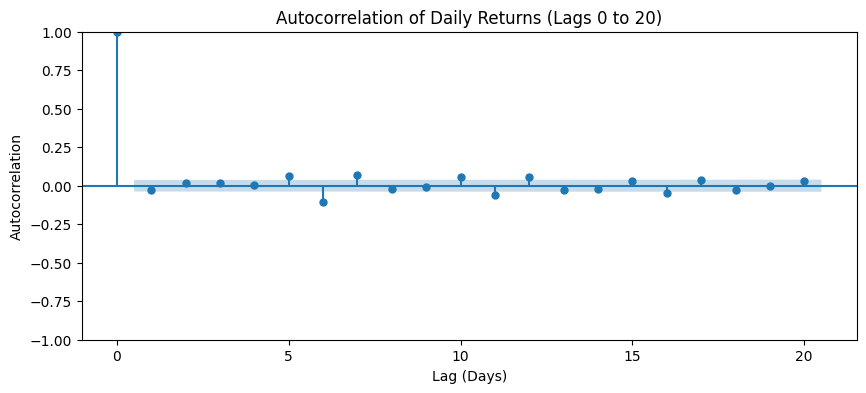

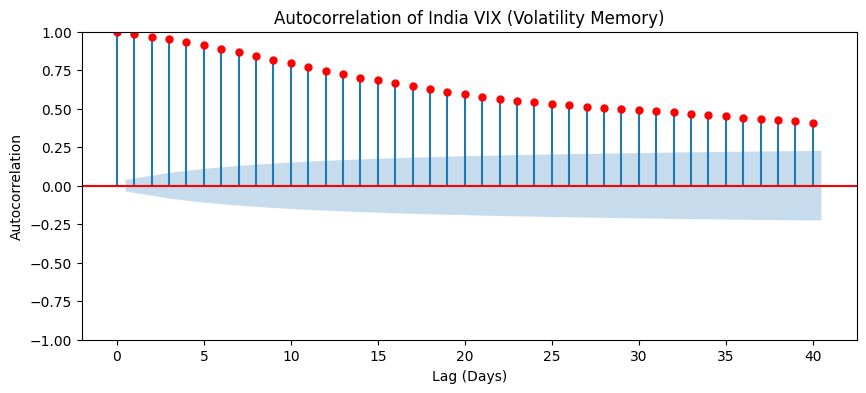

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 4))
plot_acf(df['log_ret_1d'].dropna(), lags=20, alpha=0.05, ax=plt.gca())
plt.title("Autocorrelation of Daily Returns (Lags 0 to 20)")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(df['india_vix'].dropna(), lags=40, alpha=0.05, ax=plt.gca(), color='red')
plt.title("Autocorrelation of India VIX (Volatility Memory)")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")
plt.show()

📊 What your autocorrelation plot shows
🔹 1. Lag 0 = 1 (trivial)
Always 1 → correlation with itself
🔹 2. All other lags ≈ 0
Lags 1 → 20:
Very small values
Mostly inside confidence band
No consistent pattern

👉 Interpretation:

No significant autocorrelation in daily returns

🧠 Core Insight

“Past returns do NOT predict future returns (linearly).”

This is a textbook property of financial markets.

⚠️ 3. What this means (VERY IMPORTANT)
❌ ARIMA-type models will struggle

Models relying on autocorrelation:

AR(p)
ARIMA
Linear time-series models

👉 They depend on:

𝑟
𝑡
=
𝑓
(
𝑟
𝑡
−
1
,
𝑟
𝑡
−
2
,
…
 
)
r
t
	​

=f(r
t−1
	​

,r
t−2
	​

,…)

But your data says:

There is no meaningful linear dependency

✅ Market behaves like (almost) white noise
Returns ≈ uncorrelated
Direction ≈ random (short-term)

👉 This aligns with:

Efficient Market Hypothesis (weak form)
🔥 4. But here’s the deeper truth (where quants win)

Even though:

❌ Returns are not autocorrelated
✅ Volatility IS autocorrelated
💡 What you should check next
Plot ACF of squared returns:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['log_ret_1d']**2, lags=20)

👉 You will likely see:

Strong autocorrelation
🧠 Interpretation:

“Magnitude of returns is predictable, direction is not.”

This is called:

Volatility clustering
📉 5. Why your ML model struggled (again connecting dots)

Because:

No linear signal in returns ❌
High noise environment ❌

So model learns:

“Basically random”

🚀 6. Where real predictive power comes from

Instead of raw returns, use:

✅ 1. Volatility features
Rolling std
VIX / VIX z-score
ATR
✅ 2. Regime features (you already built 👏)
Volatility quartile
200MA trend
✅ 3. Non-linear interactions
Tree models (XGBoost)
Neural nets
✅ 4. Conditional prediction

Instead of:

Predict return

Do:

Predict:
- High volatility event
- Large move (> threshold)
- Direction given regime
🧠 Final takeaway

“Returns are unpredictable in isolation, but become partially predictable when conditioned on state variables.”

### 05.Leakage Check & Baseline Correlation

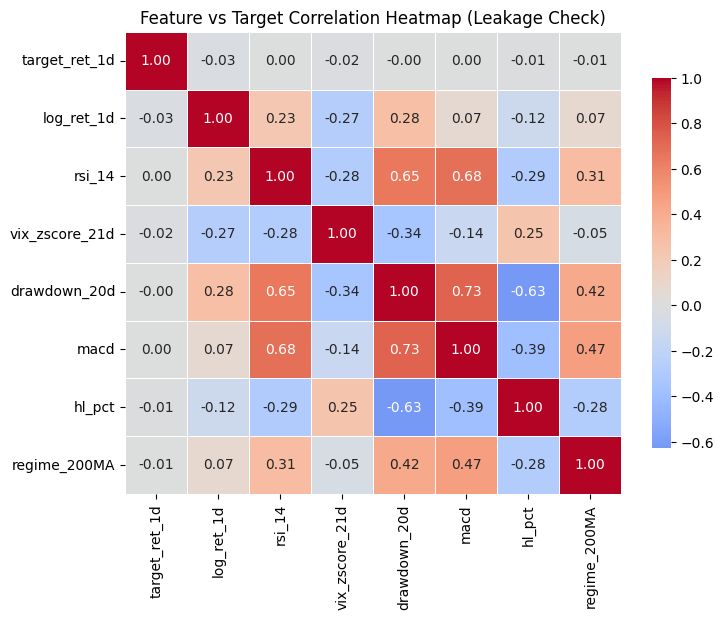

Top Positive Correlations:
log_ret_5d     0.035237
rvol_21d       0.031914
log_ret_10d    0.022851
Name: target_ret_1d, dtype: float64

Top Negative Correlations:
vix_ma_ratio_5_21   -0.045084
log_ret_1d          -0.026673
oc_pct              -0.025636
Name: target_ret_1d, dtype: float64


In [5]:
# Select a subset of features to check correlations
check_cols = ['target_ret_1d', 'log_ret_1d', 'rsi_14', 'vix_zscore_21d', 
              'drawdown_20d', 'macd', 'hl_pct', 'regime_200MA']

corr = df[check_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", 
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Feature vs Target Correlation Heatmap (Leakage Check)")
plt.show()

# Print top correlations with target
all_corr = df.corr(numeric_only=True)['target_ret_1d'].drop(['target_ret_1d', 'target_dir_1d', 'target_quintile_1d'])
print("Top Positive Correlations:")
print(all_corr.nlargest(3))
print("\nTop Negative Correlations:")
print(all_corr.nsmallest(3))